# Predicting Price Moves with News Sentiment EDA

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import (
    TfidfVectorizer,
    CountVectorizer,
    ENGLISH_STOP_WORDS,
)
from sklearn.decomposition import NMF
from nltk.stem import WordNetLemmatizer
import re

### Load data set

In [2]:
df_news = pd.read_csv('../data/news_data.csv')
df_news.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/news_data.csv'

#### Headline Length Statistics

In [ ]:
df_news['headline_length'] = df_news['headline'].astype(str).apply(len)
df_news['headline_length'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_length, dtype: float64

### Articles per publisher count

In [ ]:
publisher_counts = df_news['publisher'].value_counts()

publisher_counts.head(10)

publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64

### Publication Date Analysis

#### Convert Date Column

In [ ]:
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce')

In [ ]:
percentages = (df_news.isna().sum()/df_news.shape[0])*100
percentages

Unnamed: 0          0.000000
headline            0.000000
url                 0.000000
publisher           0.000000
date               96.021752
stock               0.000000
headline_length     0.000000
dtype: float64

## Text Analysis (Topic Modeling)

#### Words to REMOVE (Add to Stopwords)
These words are "noise." They appear in almost every headline regardless of the topic, so they don’t help your model distinguish between an earnings report and an FDA approval.
- **words like stocks, shares, market**: In a financial dataset, these are "universal" words. They don't provide specific info because nearly every headline is about a stock or the market.
- **workds like update, announces, says**: These are functional news verbs. They don't carry sentiment or topical weight.
- **benzingas**: This is a publisher name (from Benzinga). Source names should always be removed as they are pure noise.
- **years and months**: This hold no information about the effects

In [ ]:
# -----------------------------
# Clean Headlines
# -----------------------------
df_news["headline_clean"] = (
    df_news["headline"]
    .astype(str)
    .str.lower()
)

# Keep letters + numbers
df_news["headline_clean"] = df_news["headline_clean"].apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", "", x)
)

# Remove extra spaces
df_news["headline_clean"] = df_news["headline_clean"].apply(
    lambda x: re.sub(r"\s+", " ", x).strip()
)

In [ ]:
lemmatizer = WordNetLemmatizer()

df_news["headline_clean"] = df_news["headline_clean"].apply(
    lambda x: " ".join(
        lemmatizer.lemmatize(word)
        for word in x.split()
    )
)

In [ ]:
# -----------------------------
# Financial Noise Words
# -----------------------------
noise_words = [
    "stocks",
    "shares",
    "market",
    "update",
    "today",
    "daily",
    "video",
    "brief",
    "week",
    "month",
    "year",
    "52week",
    "benzingas",
    "stock",
    "session",
    "vs",
    "moving",
    "2011",
    "2012",
    "2013",
    "2014",
    "2015",
    "2016",
    "2017",
    "2018",
    "2019",
    "2020",
    "2021",
    "report"
]

stopwords = list(ENGLISH_STOP_WORDS.union(noise_words))
custom_stopwords = [lemmatizer.lemmatize(word) for word in stopwords]

### Scan (stress test) for the best max_features to choose

In [ ]:
# 1. Initialize with a high limit to see the full "long tail" of words
test_tfidf = TfidfVectorizer(
    max_features=1000, 
    stop_words=list(custom_stopwords), 
    ngram_range=(1, 2)
)

# 2. Fit and transform your cleaned headlines
tfidf_matrix = test_tfidf.fit_transform(df_news['headline_clean'].fillna(''))

# 3. Calculate the average TF-IDF score for every word
# This measures how "important" each word is across the whole dataset
feature_scores = tfidf_matrix.mean(axis=0).A1
sorted_scores = np.sort(feature_scores)[::-1] # Sort highest to lowest

### Plot (The Elbow Method)

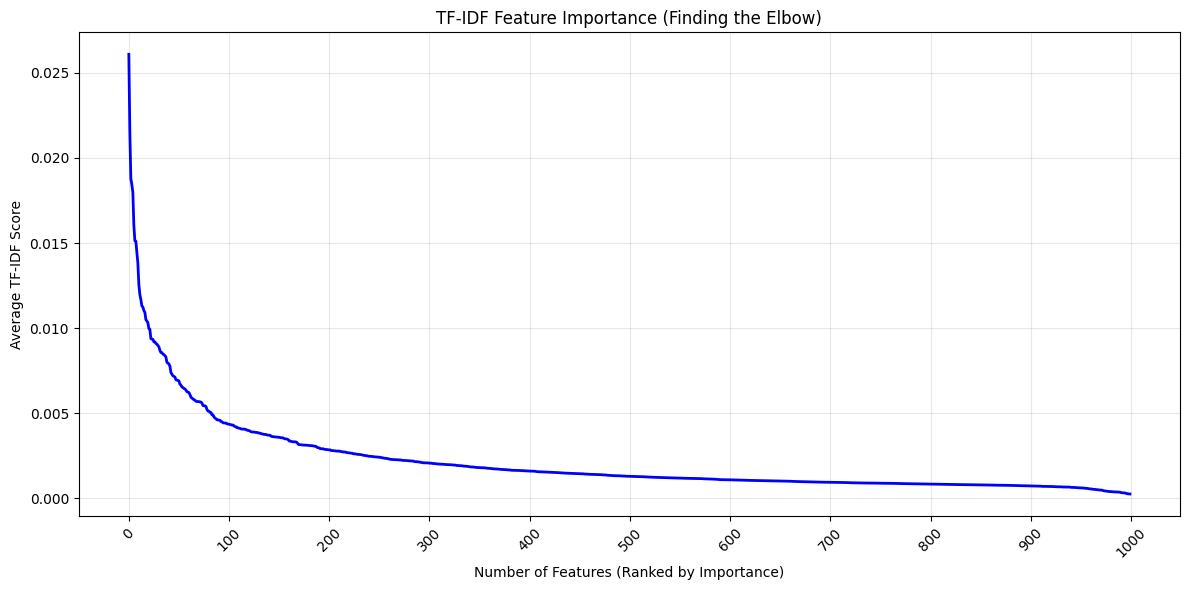

In [ ]:
plt.figure(figsize=(12, 6)) # Slightly wider to fit more labels
plt.plot(range(len(sorted_scores)), sorted_scores, linewidth=2, color='blue')

# Create a range from 0 to the end of your scores with a step of 100
plt.xticks(np.arange(0, len(sorted_scores) + 1, 100), rotation=45) 

# Formatting the chart
plt.title("TF-IDF Feature Importance (Finding the Elbow)")
plt.xlabel("Number of Features (Ranked by Importance)")
plt.ylabel("Average TF-IDF Score")
plt.grid(True, alpha=0.3)

plt.tight_layout() # Prevents labels from being cut off
plt.show()

In [ ]:
MAX_FEATURES = 100

In [ ]:
def tfidf(stop_words='english'):
    tfidf = TfidfVectorizer(
        max_features=MAX_FEATURES, stop_words=stop_words, ngram_range=(1, 2), min_df=3
    )

    tfidf_matrix = tfidf.fit_transform(df_news["headline_clean"].fillna(""))

    feature_names = tfidf.get_feature_names_out()

    # Average TF-IDF Scores
    tfidf_scores = tfidf_matrix.mean(axis=0).A1

    top_keywords = sorted(
        zip(feature_names, tfidf_scores), key=lambda x: x[1], reverse=True
    )
    
    print("Top 20 Keywords/Phrases:")

    for i, (keyword, score) in enumerate(top_keywords[:20], 1):
        print(f"{i}. {keyword}: {score:.4f}")

    # -----------------------------
    # Visualization
    # -----------------------------
    top_k = dict(top_keywords[:15])

    plt.figure(figsize=(12, 6))
    plt.barh(list(top_k.keys()), list(top_k.values()))

    plt.xlabel("TF-IDF Score")
    plt.title("Top 15 Financial News Keywords/Phrases")

    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

### Before removing custome stopwords

Top 20 Keywords/Phrases:
1. stock: 0.0595
2. market: 0.0429
3. report: 0.0421
4. share: 0.0392
5. est: 0.0346
6. earnings: 0.0337
7. update: 0.0319
8. eps: 0.0304
9. announces: 0.0291
10. benzingas: 0.0263
11. sale: 0.0257
12. downgrade: 0.0253
13. buy: 0.0251
14. etf: 0.0246
15. say: 0.0228
16. price: 0.0223
17. upgrade: 0.0222
18. pt: 0.0221
19. lower: 0.0211
20. company: 0.0201


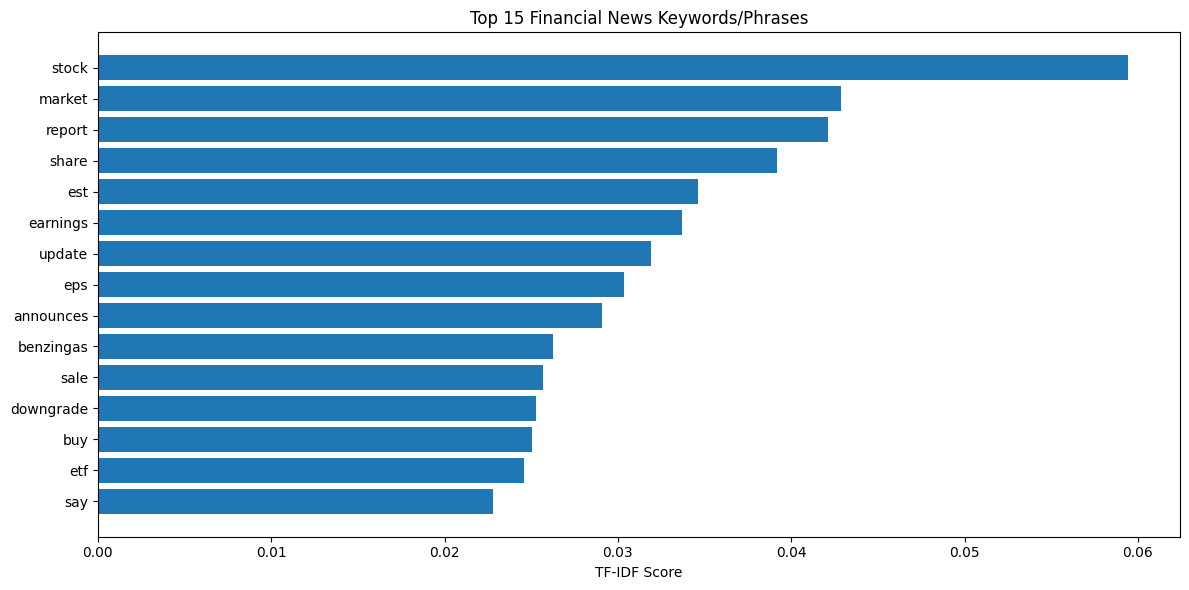

In [ ]:
tfidf()

### After Removing custome stopwords

Top 20 Keywords/Phrases:
1. earnings: 0.0358
2. est: 0.0337
3. eps: 0.0297
4. announces: 0.0295
5. downgrade: 0.0294
6. upgrade: 0.0271
7. buy: 0.0256
8. sale: 0.0255
9. etf: 0.0250
10. say: 0.0238
11. price: 0.0221
12. pt: 0.0212
13. lower: 0.0210
14. new: 0.0204
15. company: 0.0202
16. premarket: 0.0202
17. trading: 0.0197
18. higher: 0.0190
19. raise: 0.0189
20. industry: 0.0180


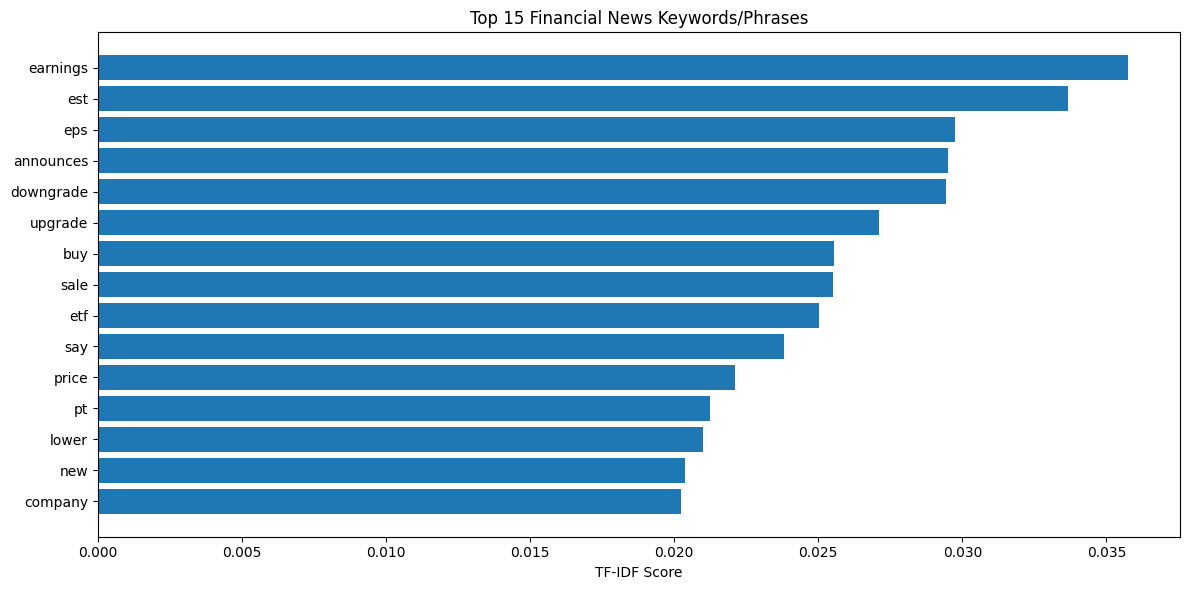

In [ ]:
tfidf(stop_words=list(custom_stopwords))

## Significant topics or recurring themes

In [ ]:
# ====================================================================
# PREPARATION: Vectorization and NMF Fitting
# ====================================================================

# We use TF-IDF for NMF as it yields much cleaner topics than raw counts
tfidf_vec = TfidfVectorizer(
    max_features=MAX_FEATURES,  # Based on your elbow plot
    stop_words=list(custom_stopwords),
    ngram_range=(1, 2)
)

tfidf_matrix = tfidf_vec.fit_transform(df_news["headline_clean"].fillna(""))
feature_names = tfidf_vec.get_feature_names_out()

# Initialize and fit NMF
n_topics = 5 
nmf_model = NMF(n_components=n_topics, random_state=42, init='nndsvd')
nmf_model.fit(tfidf_matrix)

# ====================================================================
# TOPIC EXTRACTION: Identifying Significant Topics
# ====================================================================

print("=" * 80)
print("RECURRING THEMES & SIGNIFICANT TOPICS (NMF Analysis)")
print("=" * 80)

n_words_per_topic = 10
topics_summary = []

for topic_idx, topic_weights in enumerate(nmf_model.components_):
    # Get indices of top words
    top_indices = topic_weights.argsort()[-n_words_per_topic:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    
    print(f"\n--- Topic {topic_idx + 1} ---")
    print(", ".join(top_words))
    topics_summary.append(top_words)

# ====================================================================
# TOPIC PREVALENCE
# ====================================================================
print("\n" + "=" * 80)
print("TOPIC PREVALENCE (Headline Distribution)")
print("=" * 80)

doc_topic_dist = nmf_model.transform(tfidf_matrix)
dominant_topics = doc_topic_dist.argmax(axis=1)

topic_counts = pd.Series(dominant_topics).value_counts().sort_index()
for topic_idx, count in topic_counts.items():
    percentage = (count / len(df_news) * 100)
    print(f"Topic {topic_idx + 1}: {count:>7d} articles ({percentage:>5.2f}%)")

# ====================================================================
# RECURRING PHRASES (Bigrams)
# ====================================================================
print("\n" + "=" * 80)
print("RECURRING PHRASES (Most Common 2-grams)")
print("=" * 80)

# Use CountVectorizer here because for "recurring phrases" we want pure frequency
bigram_vec = CountVectorizer(
    stop_words=list(custom_stopwords),
    ngram_range=(2, 2),
    min_df=5
)

bigram_matrix = bigram_vec.fit_transform(df_news["headline_clean"].fillna(""))
bigram_names = bigram_vec.get_feature_names_out()
phrase_freq = bigram_matrix.sum(axis=0).A1

# Sort and get top 15
top_phrase_indices = phrase_freq.argsort()[-15:][::-1]

for i, idx in enumerate(top_phrase_indices, 1):
    print(f"{i:>2d}. {bigram_names[idx]:30s} ({int(phrase_freq[idx]):>6d} occurrences)")

# ====================================================================
# FINANCIAL NEWS THEME SUMMARY (Dynamic Table)
# ====================================================================
# Instead of hardcoding, we use the actual top 3 words from NMF
themes_df = pd.DataFrame({
    'Topic': [f"Topic {i+1}" for i in range(n_topics)],
    'Identified Theme': ['TBD', 'TBD', 'TBD', 'TBD', 'TBD'], # You will fill these after seeing the output
    'Top Indicators': [", ".join(words[:5]) for words in topics_summary]
})

print("\n" + "=" * 80)
print("THEME SUMMARY TABLE (Initial Mapping)")
print("=" * 80)
print(themes_df.to_string(index=False))

RECURRING THEMES & SIGNIFICANT TOPICS (NMF Analysis)

--- Topic 1 ---
est, eps, sale, revenue, q4, q2, q1, q3, est revenue, estimate

--- Topic 2 ---
announces, price, buy, target, pt, maintains, price target, raise, lower, initiate

--- Topic 3 ---
earnings, scheduled, earnings scheduled, option, alert, option alert, higher, beat, analyst, following

--- Topic 4 ---
downgrade, upgrade, neutral, hold, buy, bank, pt, outperform, capital, morgan

--- Topic 5 ---
etf, watch, new, benzinga, midday, sector, high, energy, 10, low

TOPIC PREVALENCE (Headline Distribution)
Topic 1:  473977 articles (33.68%)
Topic 2:  415085 articles (29.49%)
Topic 3:  113731 articles ( 8.08%)
Topic 4:  101283 articles ( 7.20%)
Topic 5:  303252 articles (21.55%)

RECURRING PHRASES (Most Common 2-grams)
 1. price target                   ( 47710 occurrences)
 2. earnings scheduled             ( 32062 occurrences)
 3. initiate coverage              ( 29041 occurrences)
 4. raise pt                       ( 27232 o

## **Time Series Analysis of News Volume**

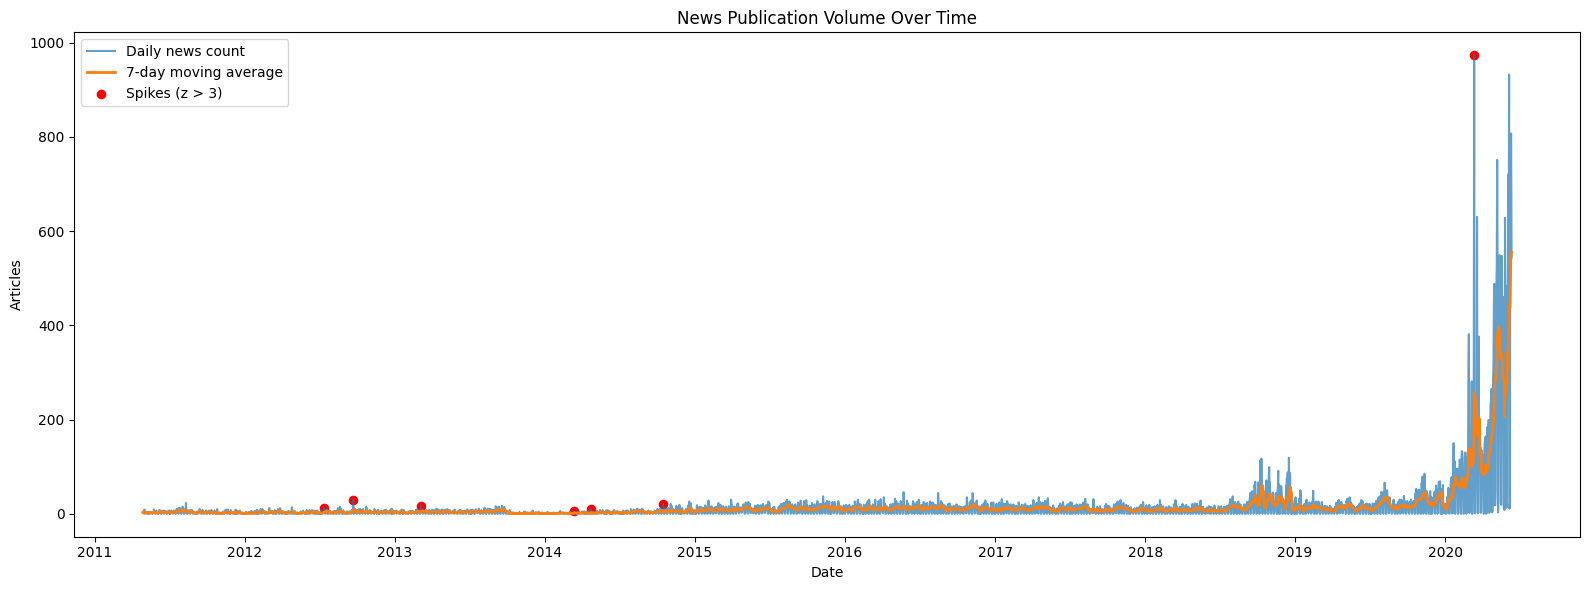

Top spike days:


,news_count,ma_7d,zscore
date,,,
2012-09-21,30,7.285714,4.042676
2020-03-12,973,258.000000,3.834594
2014-04-22,11,2.428571,3.530177
2013-03-05,17,5.285714,3.164602
2014-10-15,20,6.428571,3.095666
2012-07-12,13,3.142857,3.023829
2014-03-12,5,1.285714,3.020000


Spike days and nearest major market events:


,news_count,zscore,nearest_event,event_date,days_from_event
date,,,,,
2012-09-21,30,4.042676,COVID-19 WHO Pandemic Declaration,2020-03-11,2728
2020-03-12,973,3.834594,COVID-19 WHO Pandemic Declaration,2020-03-11,1
2014-04-22,11,3.530177,COVID-19 WHO Pandemic Declaration,2020-03-11,2150
2013-03-05,17,3.164602,COVID-19 WHO Pandemic Declaration,2020-03-11,2563
2014-10-15,20,3.095666,COVID-19 WHO Pandemic Declaration,2020-03-11,1974
2012-07-12,13,3.023829,COVID-19 WHO Pandemic Declaration,2020-03-11,2799
2014-03-12,5,3.020000,COVID-19 WHO Pandemic Declaration,2020-03-11,2191


In [ ]:
date_series = pd.to_datetime(df_news["date"], errors="coerce").dropna()

if date_series.dt.tz is not None:
    date_series = date_series.dt.tz_convert("UTC").dt.tz_localize(None)

# Daily publication volume
daily_counts = (
    date_series.dt.floor("D")
    .value_counts()
    .sort_index()
    .asfreq("D", fill_value=0)
    .rename("news_count")
)

daily_trend = pd.DataFrame(daily_counts)
daily_trend["ma_7d"] = daily_trend["news_count"].rolling(7, min_periods=1).mean()
daily_trend["std_30d"] = daily_trend["news_count"].rolling(30, min_periods=7).std()
daily_trend["zscore"] = (daily_trend["news_count"] - daily_trend["ma_7d"]) / daily_trend["std_30d"]

spikes = daily_trend[daily_trend["zscore"] > 3].copy().sort_values("zscore", ascending=False)

# Plot daily volume and spikes
plt.figure(figsize=(16, 6))
plt.plot(daily_trend.index, daily_trend["news_count"], label="Daily news count", alpha=0.7)
plt.plot(daily_trend.index, daily_trend["ma_7d"], label="7-day moving average", linewidth=2)

if not spikes.empty:
    plt.scatter(spikes.index, spikes["news_count"], color="red", s=35, label="Spikes (z > 3)")

plt.title("News Publication Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Articles")
plt.legend()
plt.tight_layout()
plt.show()

print("Top spike days:")
display(spikes.head(10)[["news_count", "ma_7d", "zscore"]])

if "major_events" not in globals():
    major_events = pd.DataFrame({
        "event": [
            "COVID-19 WHO Pandemic Declaration",
            "Fed Emergency Rate Cut",
            "US Election Day",
            "Pfizer Vaccine Efficacy News"
        ],
        "event_date": pd.to_datetime(["2020-03-11", "2020-03-15", "2020-11-03", "2020-11-09"])
    })

if not spikes.empty:
    def nearest_event(d):
        delta = (major_events["event_date"] - d).abs()
        idx = delta.idxmin()
        return pd.Series({
            "nearest_event": major_events.loc[idx, "event"],
            "event_date": major_events.loc[idx, "event_date"],
            "days_from_event": abs((d - major_events.loc[idx, "event_date"]).days)
        })

    spike_events = spikes.head(15).copy()
    spike_events = spike_events.join(spike_events.index.to_series().apply(nearest_event))
    print("Spike days and nearest major market events:")
    display(spike_events[["news_count", "zscore", "nearest_event", "event_date", "days_from_event"]])

### Analyze publishing times

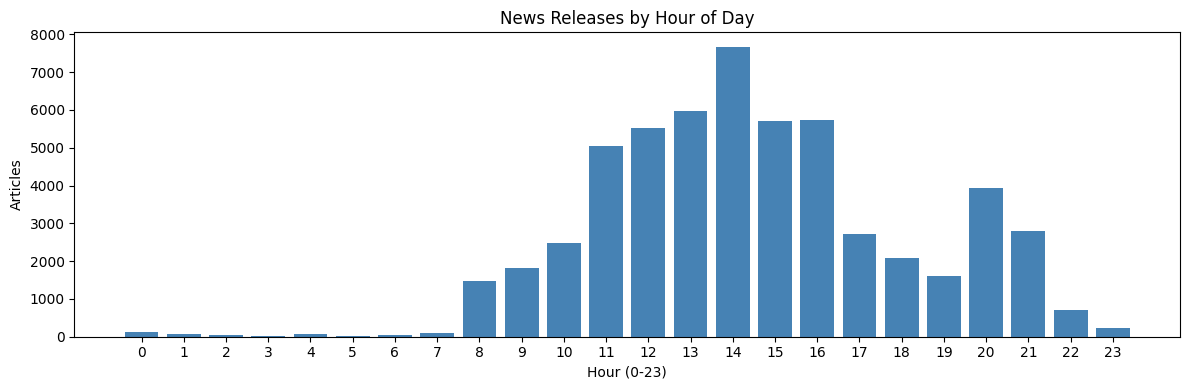

Peak publishing hour: 14:00 with 7669 articles


In [ ]:
# Intraday / time-of-day analysis
hour_series = date_series.dt.hour.dropna()
hour_counts = hour_series.value_counts().sort_index()

if hour_counts.empty or hour_counts.shape[0] <= 1:
    print("Time-of-day analysis is not available from the date column.")
else:
    plt.figure(figsize=(12, 4))
    plt.bar(hour_counts.index, hour_counts.values, color="steelblue")
    plt.xticks(range(0, 24))
    plt.title("News Releases by Hour of Day")
    plt.xlabel("Hour (0-23)")
    plt.ylabel("Articles")
    plt.tight_layout()
    plt.show()

    peak_hour = hour_counts.idxmax()
    print(f"Peak publishing hour: {peak_hour}:00 with {hour_counts.max()} articles")

## **Publisher Analysis**

In [ ]:
publisher_series = df_news["publisher"].astype(str).str.strip()
email_mask = publisher_series.str.contains("@", na=False)

# Extract organization/domain for email-based publisher names
publisher_org = publisher_series.where(~email_mask, publisher_series.str.extract(r"@([^>\s]+)$", expand=False).fillna(publisher_series))
publisher_org = publisher_org.str.lower()

publisher_activity = publisher_org.value_counts()

print("Top 20 most active publishers / organizations:")

# --- FIX: Move the index to a column so the headers align side-by-side ---
publisher_df = publisher_activity.head(20).reset_index()
publisher_df.columns = ["Publisher", "Article Count"]

display(publisher_df)

Top 20 most active publishers / organizations:


,Publisher,Article Count
0,paul quintaro,228373
1,lisa levin,186979
2,benzinga newsdesk,150484
3,charles gross,96732
4,monica gerson,82380
5,eddie staley,57254
6,hal lindon,49047
7,etf professor,28489
8,juan lopez,28438
9,benzinga staff,28114


### Analyze email domains separately

In [ ]:
email_domains = (
    publisher_series[email_mask]
    .str.extract(r"@([^>\s]+)$", expand=False)
    .str.lower()
)

if not email_domains.empty:
    domain_counts = email_domains.value_counts()
    print("\nTop 20 email domains (organizational contribution patterns):")
    domain_df = domain_counts.head(20).reset_index()
    domain_df.columns = ["Publisher Organization Domain", "Article Count"]

    display(domain_df)
else:
    print("\nNo email-style publisher names found.")


Top 20 email domains (organizational contribution patterns):


,Publisher Organization Domain,Article Count
0,benzinga.com,7937
1,gmail.com,139
2,andyswan.com,5
3,investdiva.com,2
4,tothetick.com,2
5,eosdetroit.io,1
6,forextraininggroup.com,1
7,stockmetrix.net,1


### Characterize coverage by dominant topic

In [ ]:
topic_matrix = doc_topic_dist
if "topic_matrix" in globals():
    doc_topic_dist = topic_matrix
elif "nmf_model" in globals() and "tfidf_vec" in globals():
    doc_topic_dist = nmf_model.transform(tfidf_vec.transform(df_news["headline_clean"].fillna("")))
else:
    doc_topic_dist = None

if doc_topic_dist is not None:
    dominant_topic = doc_topic_dist.argmax(axis=1)
    topic_labels = [
        f"Topic {i+1}: {', '.join(words[:3])}"
        for i, words in enumerate(topics_summary)
    ]

    top_publishers = publisher_activity.head(10).index

    coverage_rows = []
    for pub in top_publishers:
        mask = publisher_org == pub
        topic_share = (
            pd.Series(dominant_topic[mask]).value_counts(normalize=True).sort_values(ascending=False)
        )
        top_topics = [
            f"{topic_labels[t]} ({share:.1%})"
            for t, share in topic_share.head(3).items()
        ]
        coverage_rows.append({
            "publisher": pub,
            "articles": int(mask.sum()),
            "top_topics": " | ".join(top_topics)
        })

    coverage_df = pd.DataFrame(coverage_rows).sort_values("articles", ascending=False)

    print("\nCoverage characterization for the most active publishers:")
    display(coverage_df)


Coverage characterization for the most active publishers:


,publisher,articles,top_topics
0,paul quintaro,228373,"Topic 1: est, eps, sale (51.3%) | Topic 2: ann..."
1,lisa levin,186979,"Topic 5: etf, watch, new (57.7%) | Topic 4: do..."
2,benzinga newsdesk,150484,"Topic 2: announces, price, buy (37.3%) | Topic..."
3,charles gross,96732,"Topic 1: est, eps, sale (33.6%) | Topic 2: ann..."
4,monica gerson,82380,"Topic 1: est, eps, sale (29.6%) | Topic 3: ear..."
5,eddie staley,57254,"Topic 2: announces, price, buy (39.8%) | Topic..."
6,hal lindon,49047,"Topic 1: est, eps, sale (49.1%) | Topic 2: ann..."
7,etf professor,28489,"Topic 5: etf, watch, new (92.2%) | Topic 1: es..."
8,juan lopez,28438,"Topic 2: announces, price, buy (75.0%) | Topic..."
9,benzinga staff,28114,"Topic 1: est, eps, sale (42.2%) | Topic 2: ann..."
